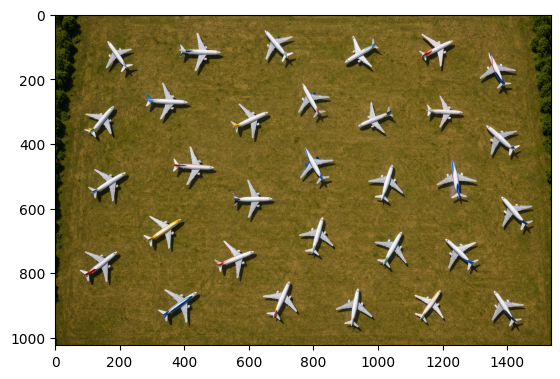

In [1]:
from matplotlib import image 
from PIL import Image 
from matplotlib import pyplot as plt
import numpy as np
from random import shuffle


#First let`s load and examine the entire image:
data_path = "data/"
file_name = "aircraft_image.bmp"
full_img = image.imread(data_path + file_name)
plt.imshow(full_img)

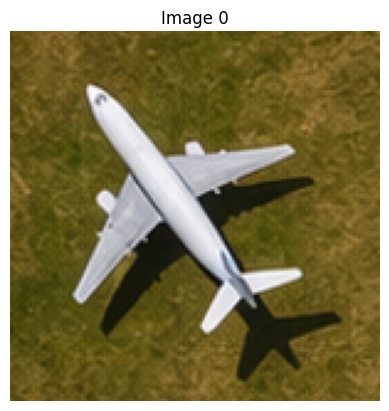

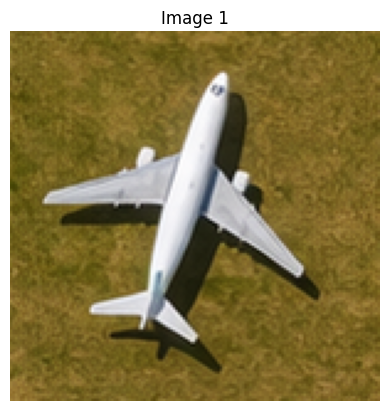

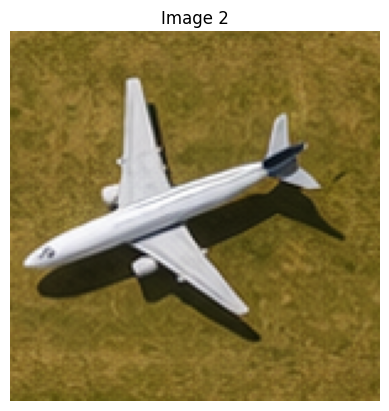

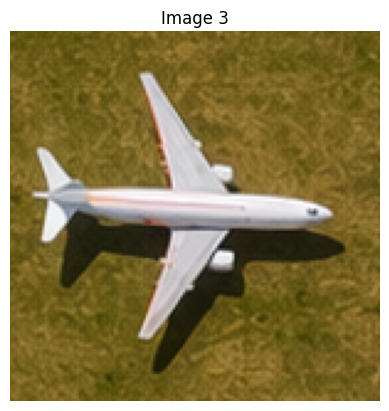

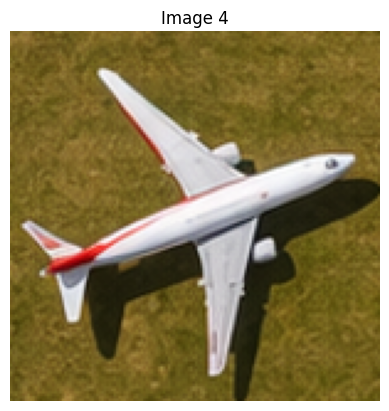

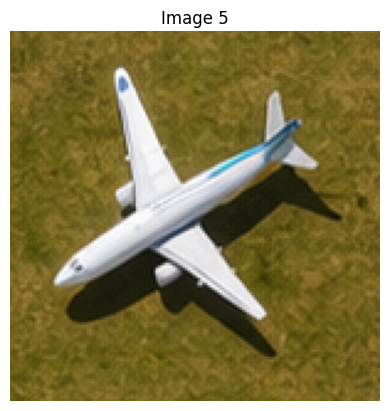

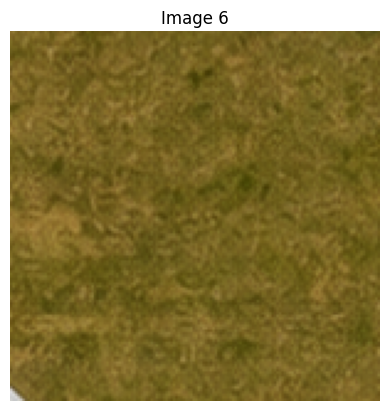

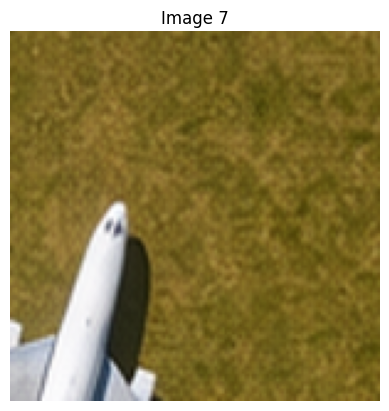

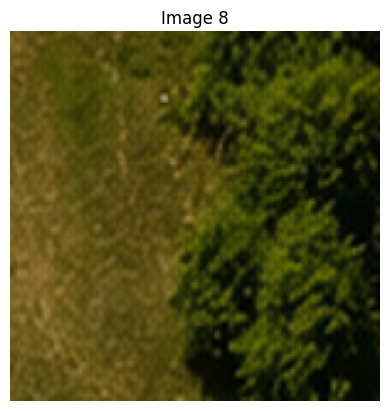

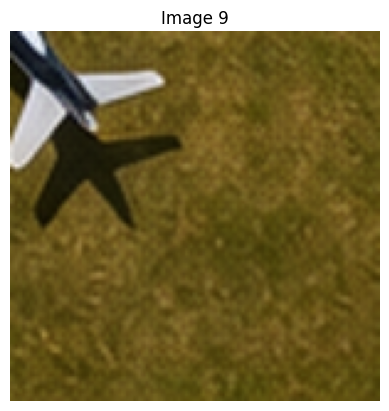

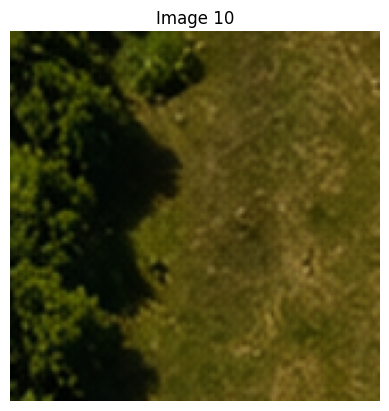

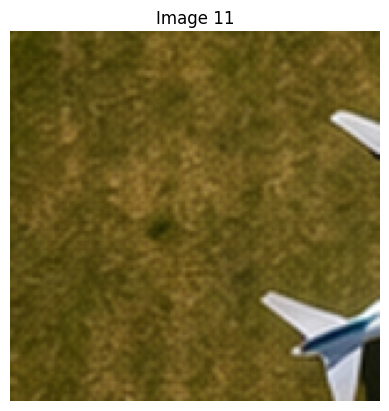

In [2]:
# Now we load each example
# First we open our training image (dimensions WxH) 
img_w = 150
img_h = 150
imgs_files = [  "positive_example_01.bmp", "positive_example_02.bmp" , "positive_example_03.bmp",
                "positive_example_04.bmp", "positive_example_05.bmp", "positive_example_06.bmp", 
                "negative_example_01.bmp", "negative_example_02.bmp", "negative_example_03.bmp", 
                "negative_example_04.bmp", "negative_example_05.bmp", "negative_example_06.bmp"] 
training_dataset_size = len(imgs_files)
imgs = []
for img_name in imgs_files:
    imgs.append( Image.open(data_path + img_name).convert("RGB").resize((img_w, img_h)))

for i, img in enumerate(imgs):
    plt.imshow(img)
    plt.title(f"Image {i}")
    plt.axis("off")  # axis removal
    plt.show()

In [3]:
# Now we flatten each image:
x = np.array([ np.array(img).flatten()/np.linalg.norm(np.array(img).flatten()) for img in imgs]) 
y = np.array([1, 1, 1, 1, 1, 1,  0 , 0, 0, 0, 0, 0])
y = y.reshape(-1,1)
print(x.shape)
print(y.shape)
print("Number of examples: ", x.shape[0])
print("Number of features: ", x.shape[1])
print(x[0])
print(len(x[0]))

(12, 67500)
(12, 1)
Number of examples:  12
Number of features:  67500
[0.00372569 0.00334936 0.00094083 ... 0.00421493 0.00346226 0.001129  ]
67500


In [4]:
# We use k-means to estimate centers for each neuron
from sklearn.cluster import KMeans
from itertools import combinations

n_neurons = 10
kmeans = KMeans(n_clusters=n_neurons, random_state=0)
kmeans.fit(x)
centers = kmeans.cluster_centers_
centers /= np.linalg.norm(centers, axis=1, keepdims=True)

dists = [np.linalg.norm(c1 - c2) for c1,c2 in combinations(centers, 2)]
sigma = np.mean(dists)

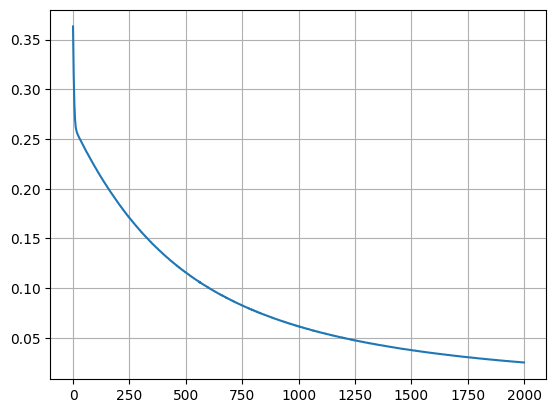

In [5]:
# Now we build and train our RBF neural network:
from random import shuffle
from rbf_nn_model import RBFNeuralNetwork

np.random.seed(666)

def fcn(x):
    return (1/(1+np.exp(-x)))

def d_fcn(x):
    return  fcn(x)*(1-fcn(x))
    
#sigma = 0.5* np.sqrt(x.shape[1]) # to avoid the curse of dimensionality
rbf_neural_network = RBFNeuralNetwork(x.shape[1],10,1,sigma, fcn, d_fcn)

# set centers using k-means, based on input feature vector
for i in range(rbf_neural_network.n_neurons -1 ):
    rbf_neural_network.neurons[i].center = centers[i].reshape(-1,1)
    
n_epochs = 2000
eta = 0.01 
indices = list( range(x.shape[0]) )
mse = []
for i in range(n_epochs):
    shuffle(indices)
    squared_error = []
    for k in indices:
        y_d = y[k]
        x_in = x[k]
        x_in = x_in.reshape(-1,1)
        e = rbf_neural_network.learn(x_in, y_d, eta)
        squared_error.append(e**2)
    mse.append( np.mean(squared_error) )

plt.plot(mse)
plt.grid()
plt.show()

In [6]:
# now we try to classify each patch along the entire image

window_step = 4
patch_size = 150
img = np.array(full_img)
rows , columns, _ = img.shape
#print(rows)
#print(columns)
results = []
for i in range(0, rows - patch_size + 1, window_step):
    for j in range(0, columns - patch_size + 1, window_step):
        patch = img[i:i+patch_size, j:j+patch_size]
        x = patch.flatten().reshape(-1,1)  #patch vectorization
        x = x/np.linalg.norm(x) # patch normalization
        y_e = rbf_neural_network.output(x)
        if y_e > 0.70:
            results.append((i, j, 1))   # aircraft detected
        else:
            results.append((i, j, 0))    # aircraft not detected

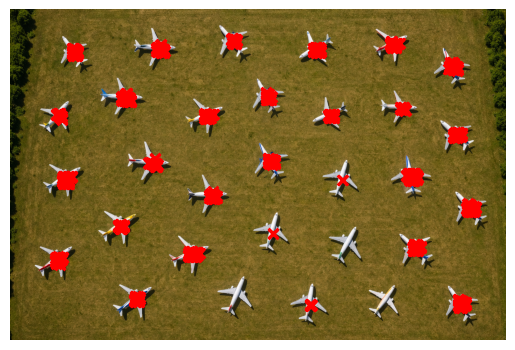

In [7]:
plt.imshow(full_img)
plt.axis("off")

for (i, j, c) in results:
    if c == 1:
        # centro do patch
        y_center = i + patch_size // 2
        x_center = j + patch_size // 2
        plt.scatter(x_center, y_center, marker='x', s=50, c= 'red', linewidths = 2)

plt.show()